# Exploratory Data Analysis of Fama–French dataset

This notebook is intended for detailed exploratory analysis of the raw factor
series: plots, correlations, seasonal effects, etc.  (Content to be added.)

In [1]:
import sys, os
root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, root)
sys.path.insert(0, os.path.join(root, "src"))

import pandas as pd
import matplotlib.pyplot as plt
from src.data.loader import load_fama_french

# load data
X, y, dates = load_fama_french('data/raw/F-F_Research_Data_5_Factors_2x3.csv')
df = pd.DataFrame(X, columns=['Mkt-RF','SMB','HML','RMW','CMA'])
df['Date'] = pd.to_datetime(dates, format='%Y%m')
df['ExcessRet'] = y

df.head()

,Mkt-RF,SMB,HML,RMW,CMA,Date,ExcessRet
0,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,1963-07-01,0.0508
1,0.0508,-0.0080,0.0170,0.0040,-0.0038,1963-08-01,-0.0157
2,-0.0157,-0.0043,0.0000,-0.0078,0.0015,1963-09-01,0.0254
3,0.0254,-0.0134,-0.0004,0.0279,-0.0225,1963-10-01,-0.0086
4,-0.0086,-0.0085,0.0173,-0.0043,0.0227,1963-11-01,0.0183


           Mkt-RF         SMB         HML         RMW         CMA  \
count  816.000000  816.000000  816.000000  816.000000  816.000000   
mean     0.005947    0.002523    0.002917    0.002351    0.002227   
min     -0.231900   -0.155400   -0.138300   -0.189500   -0.070800   
25%     -0.019125   -0.014825   -0.013525   -0.008500   -0.010500   
50%      0.009750    0.000800    0.002300    0.002150    0.000800   
75%      0.033375    0.020725    0.017000    0.012900    0.014725   
max      0.161000    0.184600    0.128600    0.130500    0.090100   
std      0.043668    0.030247    0.028918    0.021773    0.020649   

                                Date   ExcessRet  
count                            816  816.000000  
mean   1992-04-06 01:40:35.294117632    0.005951  
min              1963-07-01 00:00:00   -0.231900  
25%              1974-10-24 06:00:00   -0.019125  
50%              1991-10-16 12:00:00    0.009750  
75%              2008-10-08 18:00:00    0.033375  
max              2025

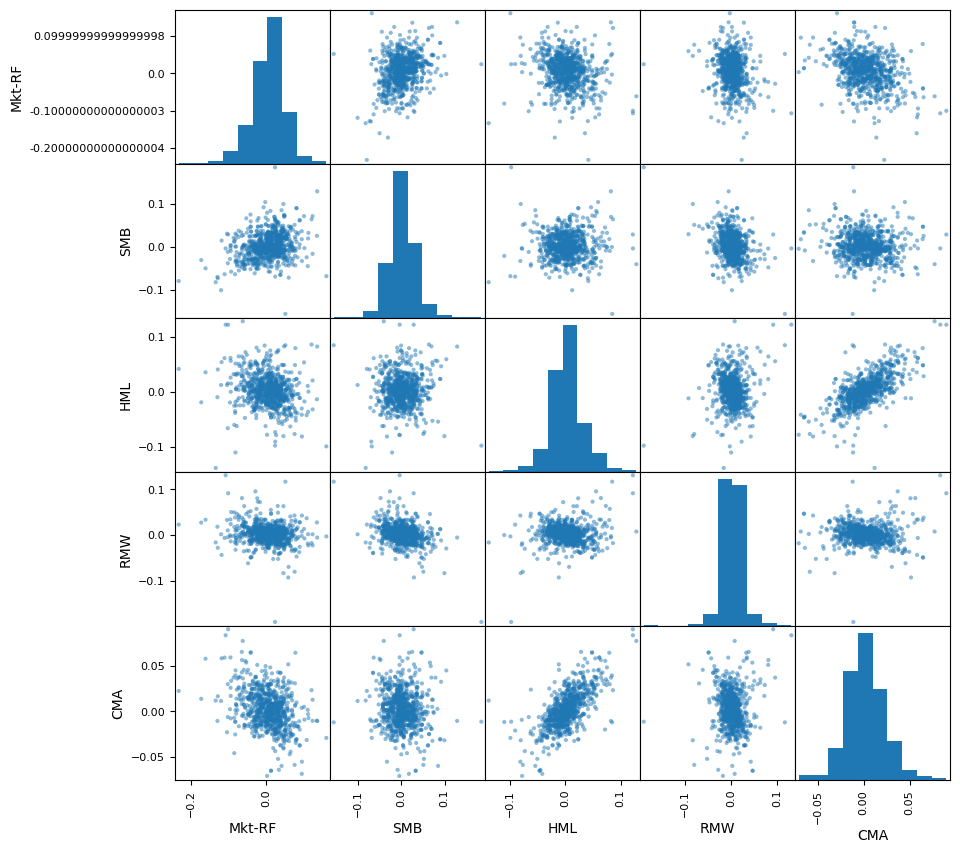

In [2]:
# basic statistics
print(df.describe())

# correlation matrix
corr = df[['Mkt-RF','SMB','HML','RMW','CMA','ExcessRet']].corr()
print(corr)

# pairplot-like scattermatrix
pd.plotting.scatter_matrix(df[['Mkt-RF','SMB','HML','RMW','CMA']], figsize=(10,10));

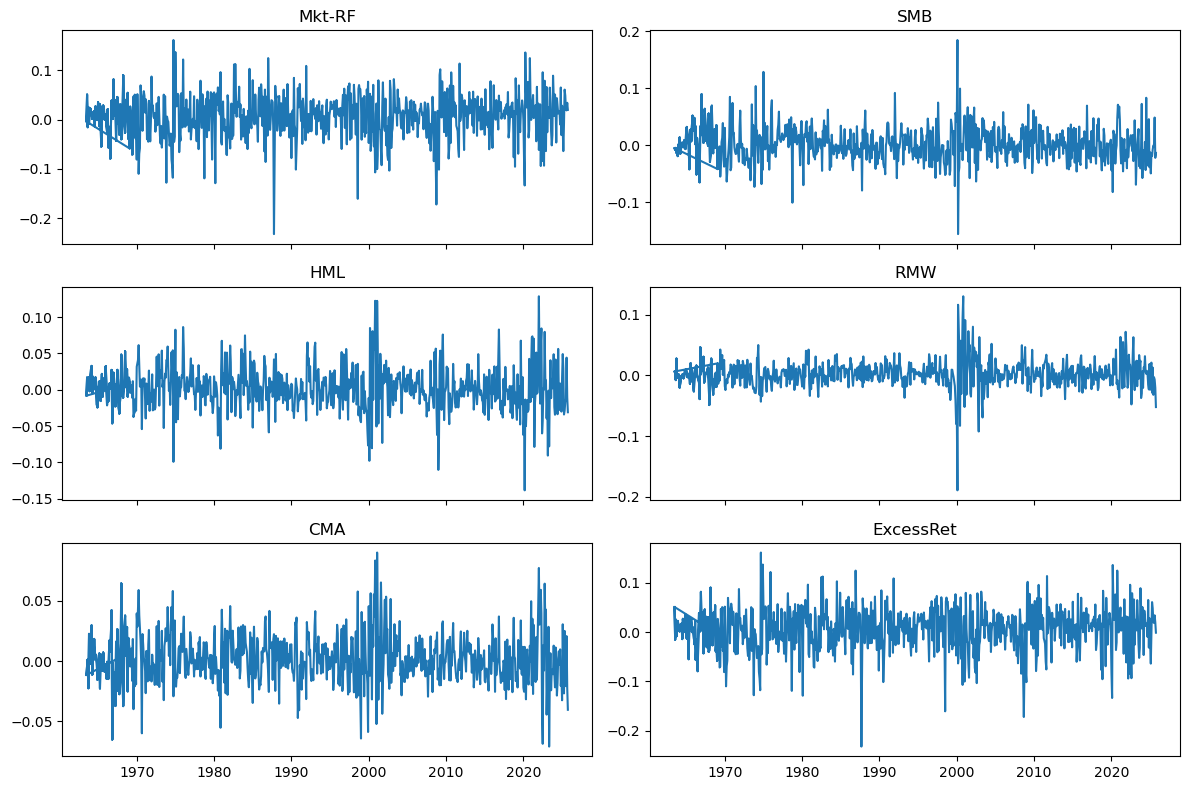

In [3]:
# time series plots of each factor
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3,2,figsize=(12,8), sharex=True)
for ax, col in zip(axes.flatten(), ['Mkt-RF','SMB','HML','RMW','CMA','ExcessRet']):
    ax.plot(df['Date'], df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Additional ideas

* Check for autocorrelation or seasonality.
* Compute rolling means/volatility.
* Visualize distributions (histograms, KDE).